<a href="https://colab.research.google.com/github/VarvaraSharutina/bioinfo/blob/main/bionf_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Математические методы биоинформатики

### Home work 6. Задача обучения с учителем - классификация. Отбор признаков.

### Задание.

В файле *gliomas_proteomics.xlsx* представлены протеомные данные пациентов с опухолями головного мозга (файл из предыдущей домашней работы). Необходимо разработать классификатор для предсказания одного из трех подтипов опухоли (целевая переменная *diagnoses.primary_diagnosis*): *'Oligodendroglioma, anaplastic'*, *'Astrocytoma, anaplastic'* или *'Mixed glioma'*.

Выполните следующие задания:

1) Проведите полный цикл предварительной обработки данных (необходимо устранить все замечания по предобработке из предыдущей домашней работы, если они были).  

2) Сформируйте подмножество признаков (subset2), статистически значимо отличающихся между классами в результате множественного тестирования (аналогично, необходимо устранить все замечания по статистическому анализу из предыдущей домашней работы, если они были).

3) Примените рассмотренные на лекции модели классификации к сформированному подмножеству данных (AdaBoost, градиентный бустинг, многослойный персептрон).  
- Для каждой модели выполните подбор гиперпараметров с помощью Байесовской оптимизации.
- Используйте аналогичные метрики оценки качества, которые использовали в предыдущей домашней работе.  

4) Примените к подмножеству признаков subset2 метод фильтрации, основанный на взаимной информации.  
- Отсортируйте признаки в порядке убывания важности.  
- Рассмотрите подмножества наиболее важных признаков (от 1 до len(subset2)) и для каждого подмножества настройте гиперпараметры и обучите модель градиентного бустинга. Выберите оптимальное подмножество признаков и оптимальную комбинацию гиперпараметров для данного подмножества.  
- Постройте график зависимости кросс-валидационной метрики качества в зависимости от числа признаков в подмножестве наиболее важных признаков. Особым образом обозначьте на графике оптимальную точку.  

5) К модели случайный лес, оптимизированной на наборе признаков subset2 в предыдущей домашней работе (т.е. используйте оптимальную комбинацию гиперпараметров для данной модели и данного подмножества, полученную в прошлый раз) необходимо применить процедуру рекурсивного отбора признаков RFECV.
- Используйте параметры step=1, min_features_to_select=1.  
- Определите оптимальное число признаков, полученное в результате RFE.  
- Постройте график зависимости кросс-валидационной метрики качества в зависимости от числа признаков в рекурсивно отбираемом подмножестве. Особым образом обозначьте на графике оптимальную точку.  

6) Среди всех моделей, рассмотренных в этой и предыдущей домашней работе, выберите лучшую модель на основе кросс-валидационных метрик качества. Вычислите для этой модели метрики качества на тестовой выборке. Постройте матрицу ошибок, вычислите чувствительность и специфичность модели для каждого класса. Сделайте выводы, позволили ли новые модели и более тщательный отбор признаков улучшить качество классификации.

In [85]:
!pip install scikit-optimize

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import warnings
from scipy.stats import kruskal
from statsmodels.stats.multitest import multipletests
from sklearn.preprocessing import StandardScaler, LabelEncoder
from scipy import stats
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
from sklearn.metrics import make_scorer, f1_score, balanced_accuracy_score
from sklearn.model_selection import cross_val_predict
from sklearn.feature_selection import mutual_info_classif


url = "https://raw.githubusercontent.com/VarvaraSharutina/bioinfo/main/gliomas_proteomics.xlsx"
data_raw = pd.read_excel(url)

In [87]:
data_raw

,cases.submitter_id,demographic.age,demographic.gender,1433BETA,1433EPSILON,1433ZETA,4EBP1,4EBP1_pS65,4EBP1_pT37T46,4EBP1_pT70,53BP1,ACC_pS79,ACC1,AceCS1,ACETYLATUBULINLYS40,ACSL1,ACVRL1,ADAR1,AKT,AKT_pS473,AKT_pT308,Akt2,Akt2_pS474,ALKBH5,ALPHACATENIN,Ambra1_pS52,AMPK-a2_pS345,AMPKALPHA,AMPKALPHA_pT172,ANNEXIN1,ANNEXINVII,AR,ARAF,ARAF_pS299,ARID1A,ASNS,Atg3,Atg4B,Atg5,Atg7,...,TRIM25,TRIP13,TSC1,TTF1,TUBERIN,TUBERIN_pT1462,TUFM,Twist,Tyro3,U-Histone-H2B,UBAC1,UBQLN4,UGT1A,ULK1_pS757,UQCRC2,UVRAG,VASP,VAV1,VEGFR2,VHL,Vinculin,Wee1,Wee1_pS642,WIPI1,WIPI2,WTAP,XBP1,XIAP,XPA,XPF,XRCC1,YAP,YAP_pS127,YB1,YB1_pS102,YTHDF2,YTHDF3,ZAP-70,ZEB1,diagnoses.primary_diagnosis
0,TCGA-FG-A4MY,44,0.0,0.069264,0.372950,-0.519320,-0.60410,-0.379530,0.494390,-0.210410,-0.31941,0.047522,-0.393100,-0.647917,4.27750,0.354096,-0.106160,0.192050,-0.74508,0.63904,0.24815,-0.576171,-0.290120,0.048301,0.078735,0.139114,0.157232,-0.409720,-0.204310,-0.23874,0.325420,-0.29868,-0.23780,0.161280,0.196240,-0.78807,-0.262411,0.981124,-0.571738,0.380354,...,-1.119090,-1.176898,-0.008772,NaN,0.691070,0.67875,0.761839,0.116191,-0.437714,-0.298722,0.163641,0.254705,0.208018,0.580376,0.320080,-0.342105,-1.086937,-0.749122,-1.11080,-0.527901,-0.648489,-0.895943,-0.666098,-0.402414,0.565964,-0.482024,0.580990,-0.386014,-0.858867,-0.322544,-0.27421,-0.275680,-1.09340,-0.068482,-0.079755,-0.261117,-0.671932,-1.558470,0.392366,Mixed glioma
1,TCGA-DB-A4X9,33,0.0,0.182310,0.338840,-0.035191,-0.53742,-0.058336,-0.459420,-0.375550,0.21985,-0.023743,0.620170,-0.737189,4.35120,0.974522,-0.009723,0.085183,0.02213,0.20638,0.21405,-0.552195,-0.495226,-0.258412,-0.388980,0.074220,0.249589,-0.109110,0.374470,-2.49250,0.263500,-0.35104,-0.47765,0.039832,0.320720,-0.55363,-0.036324,3.883570,-0.367436,0.197920,...,-0.774338,-0.979575,0.733880,NaN,0.965500,0.21080,0.268106,0.101318,-0.316311,-0.432812,0.289291,0.140820,0.165495,0.665363,0.166814,-0.260295,-0.863021,-0.438435,-1.53250,-0.590274,-1.263594,-1.085725,-0.329304,-0.601838,1.051708,-0.175882,-0.205900,-0.157671,-1.100649,-0.075822,-0.20808,-0.045655,-1.25390,-0.138460,-0.024303,-0.180114,-0.448852,-1.696286,0.763768,Mixed glioma
2,TCGA-FG-7634,28,1.0,0.299810,0.262360,-0.553070,-0.35459,-0.068374,0.635260,-0.113780,-0.21239,0.431870,0.130940,0.083266,3.43500,0.361734,0.133030,0.100240,-0.29916,1.35670,0.89963,-0.634662,0.648147,0.022664,-0.571290,0.352258,0.055565,-0.483300,-0.022486,-1.97980,0.106080,-0.61417,-0.47881,0.085520,0.080089,-0.21020,0.459551,2.452211,-0.188041,0.115819,...,-0.475738,-1.337040,-0.056999,NaN,0.696520,0.85333,-0.418055,0.201190,-0.240970,-1.039051,0.091410,0.177153,0.430923,0.873692,0.358632,-0.093317,-1.246006,-1.390474,-1.22390,-0.486394,-1.091442,-0.500151,-0.749552,0.104475,0.636381,-0.085274,1.506100,-0.497807,-0.472401,0.024029,-0.38825,-0.504620,-1.15610,-0.110080,0.010908,-0.350363,-0.438118,-1.272206,0.418899,"Oligodendroglioma, NOS"
3,TCGA-HT-7467,54,1.0,0.315760,0.130070,-0.151660,-1.25110,-0.198960,-0.136750,-0.124820,-1.06370,-0.477980,-0.913400,-0.450940,5.80240,0.033428,0.002593,-0.142250,-0.10420,0.75384,0.50850,-1.220666,0.445173,-0.445090,-0.900440,0.187766,0.361554,0.050748,0.130790,-2.18790,0.270200,-0.73248,-0.72862,0.065950,0.103900,-0.43280,0.492270,1.856408,-0.134660,-0.079797,...,-1.827548,-0.969267,0.368500,NaN,0.569620,0.66174,-0.407692,0.164521,-0.020609,-0.634922,0.489100,0.138689,0.442859,1.407250,0.771173,-0.032081,-1.012285,-1.995306,-2.03580,-0.687496,-2.113679,-1.092932,-0.509549,0.078848,0.297654,-1.164834,2.269800,-0.660731,-1.294813,-0.135185,-0.50708,-0.604310,-1.63970,-0.262980,-0.047955,-0.668674,-1.067962,-1.451437,-0.318740,"Oligodendroglioma, NOS"
4,TCGA-HT-7689,58,0.0,0.186980,0.299770,-0.455300,-0.54562,-0.140740,0.637500,-0.059809,-0.55020,0.009640,-0.301830,-0.141101,4.15300,0.482372,0.097797,0.017592,-0.40724,0.95000,0.72839,-0.241877,0.605183,-0.228564,-0.211930,0.145399,0.013930,-0.325210,0.007935,-1.55390,0.196360,-0.37397,-0.28184,0.039128,0.20089

1. Проведите полный цикл предварительной обработки данных (необходимо устранить все замечания по предобработке из предыдущей домашней работы, если они были).

In [88]:
data_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429 entries, 0 to 428
Columns: 491 entries, cases.submitter_id to diagnoses.primary_diagnosis
dtypes: float64(488), object(3)
memory usage: 1.6+ MB


In [89]:
print(data_raw.select_dtypes(include=['object']).columns.tolist())

['cases.submitter_id', 'demographic.age', 'diagnoses.primary_diagnosis']


In [90]:
#Удалим cases.submitter_id
data_raw=data_raw.drop('cases.submitter_id', axis=1)

# Посмотрим наличие проблематичных значений в demographic.age
print(data_raw['demographic.age'].value_counts())

# Преобразуем проблематичные значения в NaN, остальные в числа
data_raw['demographic.age'] = pd.to_numeric(data_raw['demographic.age'], errors='coerce')

demographic.age
38     20
33     16
30     16
31     14
36     14
37     13
34     13
29     13
47     12
41     12
39     11
32     11
35     11
53     10
51     10
58     10
43     10
54     10
40      9
48      9
62      9
44      9
52      8
60      8
59      8
26      7
46      7
42      7
25      7
50      7
57      6
27      6
28      6
61      6
24      6
56      6
49      6
55      6
22      5
45      5
20      5
23      5
63      4
66      4
74      4
21      4
64      4
73      3
67      3
69      2
71      2
70      2
17      1
75      1
86      1
68      1
18      1
'--     1
14      1
65      1
Name: count, dtype: int64


In [91]:
# Поиск неявных дубликатов
print(data_raw['demographic.gender'].value_counts())
print("-" * 40)
print(data_raw['diagnoses.primary_diagnosis'].value_counts())
print("-" * 40)

# Удалим лишнее из целевой перменной
data_raw = data_raw[data_raw['diagnoses.primary_diagnosis'].isin(['Oligodendroglioma, anaplastic','Astrocytoma, anaplastic','Mixed glioma'])]
print("\nЗначения целевой переменной после обработки")
print(data_raw['diagnoses.primary_diagnosis'].value_counts())
print(data_raw.shape)

demographic.gender
1.0    237
0.0    191
Name: count, dtype: int64
----------------------------------------
diagnoses.primary_diagnosis
Mixed glioma                     114
Oligodendroglioma, NOS           103
Astrocytoma, anaplastic          100
Oligodendroglioma, anaplastic     64
Astrocytoma, NOS                  47
Not Reported                       1
Name: count, dtype: int64
----------------------------------------

Значения целевой переменной после обработки
diagnoses.primary_diagnosis
Mixed glioma                     114
Astrocytoma, anaplastic          100
Oligodendroglioma, anaplastic     64
Name: count, dtype: int64
(278, 490)


In [92]:
# Поиск полных дубликатов
duplicates = data_raw.duplicated().sum()
print(f"Количество полных дубликатов: {duplicates}")

# Поиск частичных дубликатов
dw=data_raw.drop('diagnoses.primary_diagnosis', axis=1)
duplicates = dw.duplicated().sum()
print(f"Количество частичных дубликатов: {duplicates}")

Количество полных дубликатов: 0
Количество частичных дубликатов: 0


In [93]:
# Обработка пропусков
data_raw.isnull().sum()[data_raw.isnull().sum() > 0]

,0
ALPHACATENIN,109
AXL,278
CA9,278
CASPASE9,278
COMPLEXIISUBUNIT30,278
CTLA4,278
E2F1,278
ENY2,278
EZH2,278
GATA6,278


In [94]:
# Удалим признаки, содержащие более 20% пропусков
cols_for_delete=data_raw.isnull().sum()[data_raw.isnull().sum() > 0].index.tolist()
data_raw=data_raw.drop(cols_for_delete, axis=1)
data_raw.isnull().sum()[data_raw.isnull().sum() > 0]

,0


In [95]:
df=data_raw
X=df.drop('diagnoses.primary_diagnosis', axis=1)
y=df['diagnoses.primary_diagnosis'] # целевая переменная

# Кодирование целевой метки
label_encoder=LabelEncoder()
y_enc=label_encoder.fit_transform(y)
classes = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(classes)

# Разделение на тестовую и обучающую выборки
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y_enc, test_size=0.2, random_state=42, stratify=y_enc)

{'Astrocytoma, anaplastic': np.int64(0), 'Mixed glioma': np.int64(1), 'Oligodendroglioma, anaplastic': np.int64(2)}



CYCLINB1
Границы: [-2.64, -0.99]
Количество выбросов: 21 
Минимальное значение выброса: -2.7268
Максимальное значение выброса: 0.4265


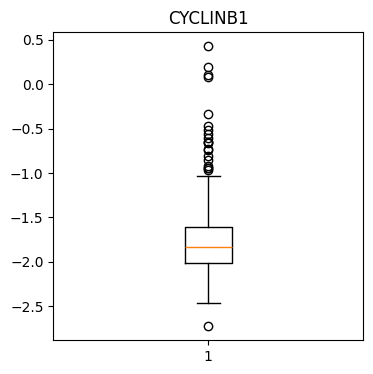


EGFR
Границы: [-0.63, 2.21]
Количество выбросов: 26 
Минимальное значение выброса: -0.66579
Максимальное значение выброса: 4.3015


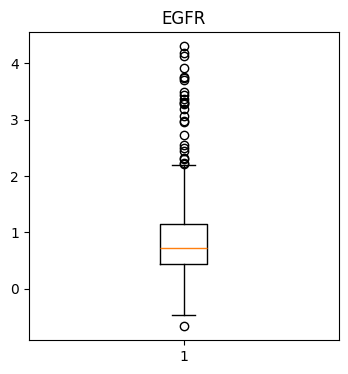


EGFR_pY1068
Границы: [-0.59, 1.73]
Количество выбросов: 25 
Минимальное значение выброса: 1.7731
Максимальное значение выброса: 8.3982


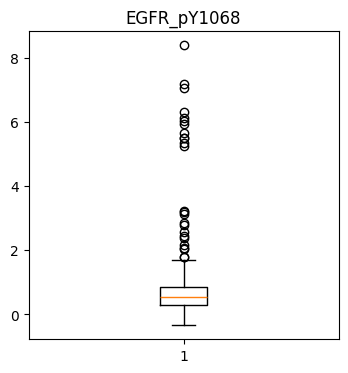


HER2
Границы: [-1.63, -0.35]
Количество выбросов: 32 
Минимальное значение выброса: -2.0947
Максимальное значение выброса: 0.83153


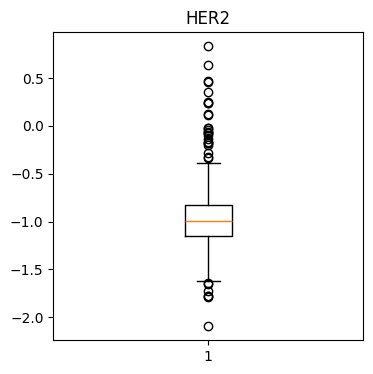


HER2_pY1248
Границы: [-0.41, 0.49]
Количество выбросов: 25 
Минимальное значение выброса: 0.48893
Максимальное значение выброса: 4.2648


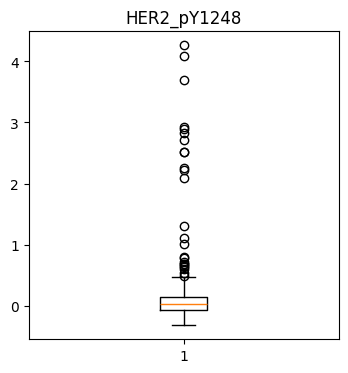


PAI1
Границы: [-1.48, 0.13]
Количество выбросов: 23 
Минимальное значение выброса: 0.1539
Максимальное значение выброса: 3.0154


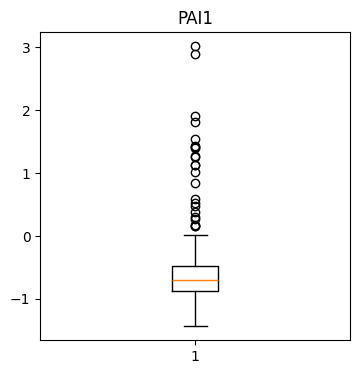


PAR
Границы: [-3.54, -1.32]
Количество выбросов: 31 
Минимальное значение выброса: -1.314142
Максимальное значение выброса: 2.485712


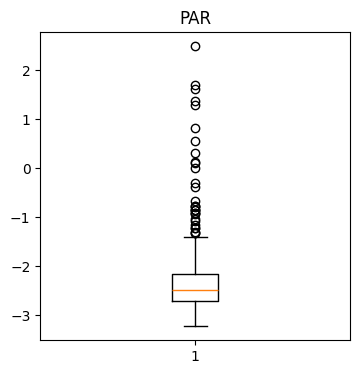


SHC_pY317
Границы: [-0.22, 0.56]
Количество выбросов: 21 
Минимальное значение выброса: -0.33083
Максимальное значение выброса: 1.9039


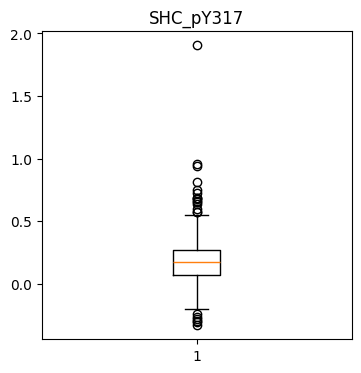


SHP2_pY542
Границы: [-0.77, 1.73]
Количество выбросов: 21 
Минимальное значение выброса: -1.0449
Максимальное значение выброса: 5.8503


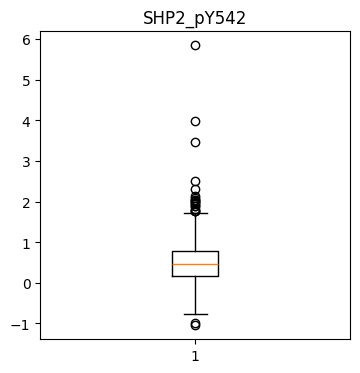


Wee1
Границы: [-1.81, 0.02]
Количество выбросов: 23 
Минимальное значение выброса: 0.02429887
Максимальное значение выброса: 1.051081


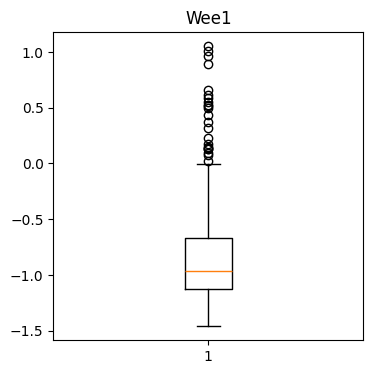

In [96]:
# Анализ выбросов
all_cols = data_raw.columns.tolist()
categorial_cols=['demographic.gender']
target_var=['diagnoses.primary_diagnosis']
numeric_cols = [col for col in all_cols if col not in categorial_cols+target_var]

def analysis_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    mini = Q1 - 1.5 * IQR
    maxi = Q3 + 1.5 * IQR
    outliers = data[(data[column] < mini) | (data[column] > maxi)]
    return outliers, mini, maxi

for col in numeric_cols:
    outliers, min, max = analysis_outliers(df, col)
    if len(outliers) > 20:
      print(f"\n{col}")
      print(f"Границы: [{min:.2f}, {max:.2f}]")
      print(f"Количество выбросов: {len(outliers)} ")
      print(f"Минимальное значение выброса: {outliers[col].min()}")
      print(f"Максимальное значение выброса: {outliers[col].max()}")
      # print(f"Bыбросы: {outliers[col].tolist()}")
      plt.figure(figsize=(4, 4))
      plt.boxplot(df[col])
      plt.title(col)
      plt.show()

С выбросами было принято решение ничего не делать, так как самое большое количество выбросов среди признаков составляет 32 образца (примерно 12% от всех образцов), из-за чего удаление признака приведёт к потере информации. Но если удалить чисто образцы, которые являются выбросами, мы также потеряем очень много информации (останется всего 3 образца из 278)

In [97]:
# z-нормализация
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

2. Сформируйте подмножество признаков (subset2), статистически значимо отличающихся между классами в результате множественного тестирования (аналогично, необходимо устранить все замечания по статистическому анализу из предыдущей домашней работы, если они были).

In [98]:
X_train_scaled_df = pd.DataFrame(X_train_scaled,columns=X_train.columns,index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled,columns=X_test.columns,index=X_test.index)

subset1 = numeric_cols +categorial_cols
print(f"Кол-во признаков в subset1: {len(subset1)}")

subset2=[]
p_values = []
features = []
X_train_orig = df.drop(columns=['diagnoses.primary_diagnosis']).loc[X_train.index]

for col in categorial_cols:
  observed = pd.crosstab(X_train_orig[col], y_train)
  groups = [X_train_orig[col][y_train == val] for val in np.unique(y_train)]
  _, p_val, _, _ = stats.chi2_contingency(observed)
  p_values.append(p_val)
  features.append(col)

for col in numeric_cols:
  groups = [X_train_orig[col][y_train == val] for val in np.unique(y_train)]
  stat, p_val = kruskal(*groups)
  p_values.append(p_val)
  features.append(col)

_, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')
subset2 = [col for col, pval in zip(features, pvals_corrected)if pval < 0.05]
print('\nТаблица сопряженности:')
print(observed)

print(f"\nКол-во признаков в subset2: {len(subset2)}")

Кол-во признаков в subset1: 458

Таблица сопряженности:
col_0                0   1   2
demographic.gender            
0.0                 41  39  24
1.0                 39  52  27

Кол-во признаков в subset2: 127


3. Примените рассмотренные на лекции модели классификации к сформированному подмножеству данных (AdaBoost, градиентный бустинг, многослойный персептрон).  
- Для каждой модели выполните подбор гиперпараметров с помощью Байесовской оптимизации.
- Используйте аналогичные метрики оценки качества, которые использовали в предыдущей домашней работе.

In [99]:
warnings.filterwarnings('ignore')
scoring = {'f1_weighted': make_scorer(f1_score, average='weighted'),'balanced_accuracy': make_scorer(balanced_accuracy_score),'roc_auc_ovr': 'roc_auc_ovr'}

models = {
    'Adaboost': (AdaBoostClassifier(),
                            {'n_estimators': Integer(10, 200),
                             'learning_rate': Real(0.01, 1, prior='log-uniform')}),
    'GradientBoosting': (GradientBoostingClassifier(),
                      {'learning_rate': Real(0.01, 1, prior='log-uniform'),
                      'n_estimators': Integer(10, 100),
                      'subsample': Real(0.5, 1),
                      'max_depth': Integer(2, 5),
                      'min_samples_split': Integer(2, 20),
                      'min_samples_leaf': Integer(1, 10),
                      'max_features': Categorical(['sqrt', 'log2', None])}),
    'MLP': (MLPClassifier(),
         {'hidden_layer_sizes': (30,),
          'activation': Categorical(['relu', 'tanh', 'logistic', 'identity']),
          'learning_rate_init': Real(0.01, 1, prior='log-uniform')}),
        }

results = []
best_models = {}
for subset_name, subset_cols in [('subset1', subset1), ('subset2', subset2)]:

    X_tr = X_train_scaled_df[subset_cols]

    for model_name, (model, params) in models.items():
      bayes_search = BayesSearchCV(model, params, n_iter=20, cv=5, scoring='f1_weighted', n_jobs=-1, random_state=42)
      bayes_search.fit(X_tr, y_train)
      best_model = bayes_search.best_estimator_
      best_models[(model_name, subset_name)] = best_model

      cv_res = cross_validate(best_model,X_tr,y_train,cv=5,scoring=scoring,n_jobs=-1)

      results.append({
          'Model': model_name,
          'Features': subset_name,
          'F1_weighted': cv_res['test_f1_weighted'].mean(),
          'Balanced Accuracy': cv_res['test_balanced_accuracy'].mean(),
          'ROC_AUC_OVR': cv_res['test_roc_auc_ovr'].mean(),
      })

results_df = pd.DataFrame(results)

print(results_df.sort_values(by='F1_weighted', ascending=False))

              Model Features  F1_weighted  Balanced Accuracy  ROC_AUC_OVR
3          Adaboost  subset2     0.587863           0.580349     0.722977
5               MLP  subset2     0.584728           0.577334     0.699467
1  GradientBoosting  subset1     0.570819           0.552714     0.731196
4  GradientBoosting  subset2     0.549362           0.531089     0.716525
0          Adaboost  subset1     0.547280           0.529565     0.713189
2               MLP  subset1     0.534982           0.546604     0.711651


4. Примените к подмножеству признаков subset2 метод фильтрации, основанный на взаимной информации.  
- Отсортируйте признаки в порядке убывания важности.  
- Рассмотрите подмножества наиболее важных признаков (от 1 до len(subset2)) и для каждого подмножества настройте гиперпараметры и обучите модель градиентного бустинга. Выберите оптимальное подмножество признаков и оптимальную комбинацию гиперпараметров для данного подмножества.  
- Постройте график зависимости кросс-валидационной метрики качества в зависимости от числа признаков в подмножестве наиболее важных признаков. Особым образом обозначьте на графике оптимальную точку.  

Hexokinase-II     0.212015
DRP1              0.153510
SYK               0.145502
HMHA1             0.140271
VAV1              0.123816
MCT4              0.112574
ACC1              0.112038
MMP14             0.106047
INPP4B            0.098656
Glutamate-D1-2    0.092950
dtype: float64


100%|██████████| 127/127 [1:21:08<00:00, 38.33s/it]


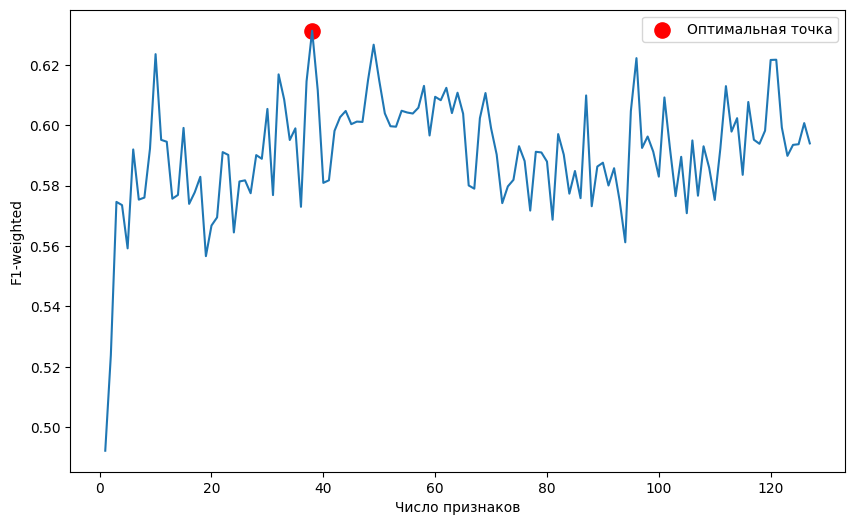

Лучшее число признаков: 38
Лучший F1_weighted: 0.6312647991864179
Лучшая модель: GradientBoostingClassifier(learning_rate=0.04168599997607915, max_depth=2,
                           max_features='sqrt', min_samples_leaf=3,
                           min_samples_split=20, n_estimators=93,
                           subsample=0.5412710785450165)


In [101]:
from sklearn.feature_selection import mutual_info_classif
from tqdm import tqdm

X_tr = X_train_scaled_df[subset2]
y_tr = y_train

mi = mutual_info_classif(X_tr, y_tr, random_state=42)
mi_series = pd.Series(mi, index=X_tr.columns)
mi_sorted = mi_series.sort_values(ascending=False)
print(mi_sorted.head(10))

sorted_features = mi_sorted.index.tolist()
k_values = list(range(1, len(sorted_features) + 1))
params = {
    'learning_rate': Real(0.01, 1, prior='log-uniform'),
    'n_estimators': Integer(10, 100),
    'subsample': Real(0.5, 1.0),
    'max_depth': Integer(2, 5),
    'min_samples_split': Integer(2, 20),
    'min_samples_leaf': Integer(1, 10),
    'max_features': Categorical(['sqrt', 'log2', None])
}
results = []

for k in tqdm(k_values):
    features_k = sorted_features[:k]
    X_k = X_tr[features_k]
    model = GradientBoostingClassifier()
    opt = BayesSearchCV(model, params, n_iter=15, cv=5, scoring='f1_weighted', n_jobs=-1, random_state=42)
    opt.fit(X_k, y_tr)
    best_score = opt.best_score_
    results.append((k, best_score))
    if best_score > best_global_score:
      best_global_score = best_score
      best_k = k
      best_model = opt.best_estimator_

results_df = pd.DataFrame(results, columns=['n_features', 'F1_weighted'])

plt.figure(figsize=(10, 6))
plt.plot(results_df['n_features'], results_df['F1_weighted'])
plt.scatter(best_k, best_global_score, color='red', s=120, label='Оптимальная точка')
plt.xlabel('Число признаков')
plt.ylabel('F1-weighted')
plt.legend()
plt.show()

print("Лучшее число признаков:", best_k)
print("Лучший F1_weighted:", best_global_score)
print("Лучшая модель:", best_model)

5. К модели случайный лес, оптимизированной на наборе признаков subset2 в предыдущей домашней работе (т.е. используйте оптимальную комбинацию гиперпараметров для данной модели и данного подмножества, полученную в прошлый раз) необходимо применить процедуру рекурсивного отбора признаков RFECV.
- Используйте параметры step=1, min_features_to_select=1.  
- Определите оптимальное число признаков, полученное в результате RFE.  
- Постройте график зависимости кросс-валидационной метрики качества в зависимости от числа признаков в рекурсивно отбираемом подмножестве. Особым образом обозначьте на графике оптимальную точку.  

In [102]:
warnings.filterwarnings('ignore')
scoring = {'f1_weighted': make_scorer(f1_score, average='weighted'),'balanced_accuracy': make_scorer(balanced_accuracy_score),'roc_auc_ovr': 'roc_auc_ovr'}

models = {
    'Logistic Regression': (LogisticRegression(),
                            {'C': (0.001, 10, 'log-uniform') }),
    'kNN': (KNeighborsClassifier(),
         {'n_neighbors': (2, 20),
          'p': [1, 2]}),
    'SVM': (SVC(probability=True),
         {'C': (0.001, 10.0, 'log-uniform'),
          'kernel': ['linear', 'rbf']}),
    'DecisionTree': (DecisionTreeClassifier(),
                      {'max_depth': (2, 20),
                        'min_samples_split': (2, 20),
                        'min_samples_leaf': (1, 10),
                        'max_features': ['sqrt', 'log2', None]}),
    'RandomForest': (RandomForestClassifier(),
                      {'n_estimators': (10, 100),
                      'max_depth': (2, 20),
                      'min_samples_split': (2, 20),
                      'min_samples_leaf': (1, 10),
                      'max_features': ['sqrt', 'log2', None]}),
    'ExtraTrees': (ExtraTreesClassifier(),
                  {'n_estimators': (10, 100),
                  'max_depth': (2, 20),
                  'min_samples_split': (2, 20),
                  'min_samples_leaf': (1, 10),
                  'max_features': ['sqrt', 'log2', None]}),
        }

results = []
best_models = {}
for subset_name, subset_cols in [('subset1', subset1), ('subset2', subset2)]:

    X_tr = X_train_scaled_df[subset_cols]

    for model_name, (model, params) in models.items():
      bayes_search = BayesSearchCV(model, params, n_iter=20, cv=5, scoring='f1_weighted', n_jobs=-1, random_state=42)
      bayes_search.fit(X_tr, y_train)
      best_model = bayes_search.best_estimator_
      best_models[(model_name, subset_name)] = best_model

      cv_res = cross_validate(best_model,X_tr,y_train,cv=5,scoring=scoring,n_jobs=-1)

      results.append({
          'Model': model_name,
          'Features': subset_name,
          'F1_weighted': cv_res['test_f1_weighted'].mean(),
          'Balanced Accuracy': cv_res['test_balanced_accuracy'].mean(),
          'ROC_AUC_OVR': cv_res['test_roc_auc_ovr'].mean(),
      })

results_df = pd.DataFrame(results)

print(results_df.sort_values(by='F1_weighted', ascending=False))

                  Model Features  F1_weighted  Balanced Accuracy  ROC_AUC_OVR
8                   SVM  subset2     0.628932           0.601686     0.789545
6   Logistic Regression  subset2     0.595685           0.576163     0.746508
7                   kNN  subset2     0.590663           0.575338     0.744573
2                   SVM  subset1     0.585801           0.566028     0.776235
0   Logistic Regression  subset1     0.570894           0.567407     0.705538
5            ExtraTrees  subset1     0.565295           0.544361     0.746358
10         RandomForest  subset2     0.560753           0.540617     0.743311
4          RandomForest  subset1     0.560057           0.538991     0.719920
11           ExtraTrees  subset2     0.540883           0.522292     0.743289
1                   kNN  subset1     0.521825           0.498218     0.670227
9          DecisionTree  subset2     0.499531           0.486047     0.642945
3          DecisionTree  subset1     0.482515           0.473334

Оптимальное число признаков: 109
Лучший F1_weighted: 0.5871485778571682
Лучшая модель: RandomForestClassifier(max_depth=5, max_features=None, min_samples_split=18)


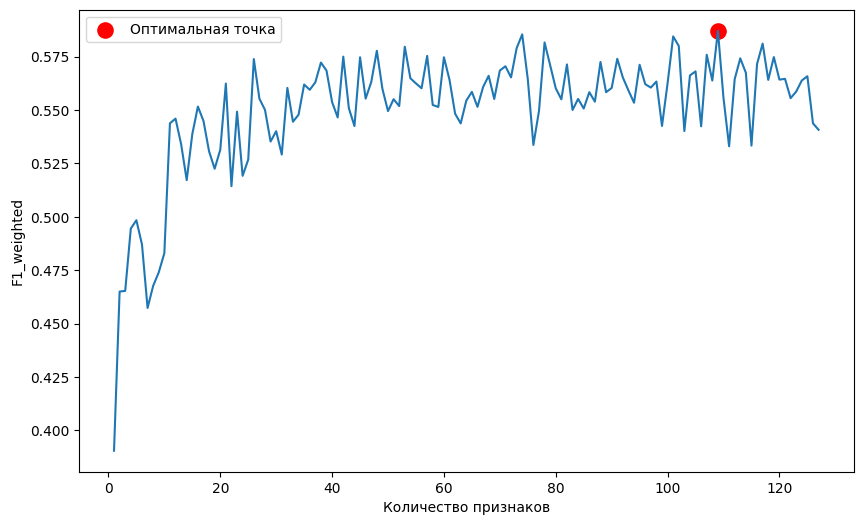

In [110]:
from sklearn.feature_selection import RFECV

best_rf = best_models[('RandomForest', 'subset2')]
rfecv = RFECV(estimator=best_rf,step=1,min_features_to_select=1,cv=5,scoring='f1_weighted',n_jobs=-1)
rfecv.fit(X_tr, y_tr)
opt_features = rfecv.n_features_
print("Оптимальное число признаков:", opt_features)
best_f1 = np.max(rfecv.cv_results_['mean_test_score'])
print("Лучший F1_weighted:", best_f1)
print("Лучшая модель:", best_rf)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), rfecv.cv_results_['mean_test_score'])
plt.scatter(opt_features,best_f1,color='red',s=120,label='Оптимальная точка')
plt.xlabel("Количество признаков")
plt.ylabel("F1_weighted")
plt.legend()
plt.show()

6. Среди всех моделей, рассмотренных в этой и предыдущей домашней работе, выберите лучшую модель на основе кросс-валидационных метрик качества. Вычислите для этой модели метрики качества на тестовой выборке. Постройте матрицу ошибок, вычислите чувствительность и специфичность модели для каждого класса. Сделайте выводы, позволили ли новые модели и более тщательный отбор признаков улучшить качество классификации.

Отобранные признаки: 56
F1_weighted: 0.625
Balanced Accuracy: 0.6157190635451505
ROC_AUC_OVR: 0.7442057825146805


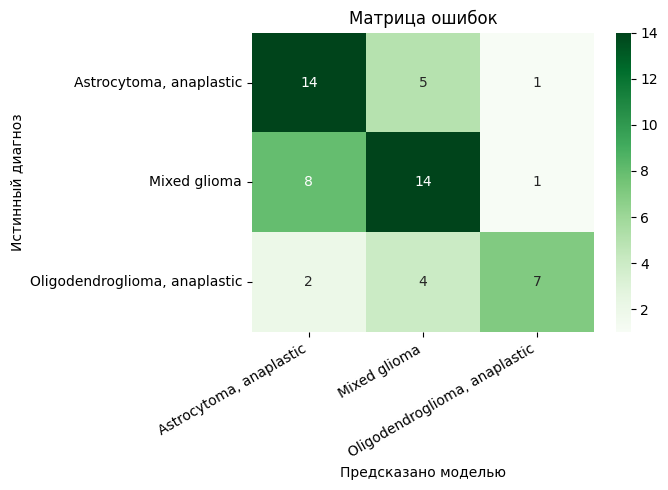

Astrocytoma, anaplastic: Чувствительность = 0.700, Специфичность = 0.722
Mixed glioma: Чувствительность = 0.609, Специфичность = 0.727
Oligodendroglioma, anaplastic: Чувствительность = 0.538, Специфичность = 0.953


In [105]:
# GradientBoosting
gb_features = sorted_features[:best_k]
print("Отобранные признаки:", len(best_features))

best_model_gb = GradientBoostingClassifier(learning_rate=0.04168599997607915, max_depth=2,
                           max_features='sqrt', min_samples_leaf=3,
                           min_samples_split=20, n_estimators=93,
                           subsample=0.5412710785450165)

X_tr_gb = X_train_scaled_df[gb_features]
X_te_gb = X_test_scaled_df[gb_features]
best_model_gb.fit(X_tr_gb, y_train)
y_pred_test_gb = best_model_gb.predict(X_te_gb)
y_proba_test_gb = best_model_gb.predict_proba(X_te_gb)

# Вычислим метрики для модели GradientBoosting
f1_gb = f1_score(y_test, y_pred_test_gb, average='weighted')
bal_acc_gb = balanced_accuracy_score(y_test, y_pred_test_gb)
roc_auc_gb = roc_auc_score(y_test, y_proba_test_gb, multi_class='ovr')
print(f"F1_weighted: {f1_gb}")
print(f"Balanced Accuracy: {bal_acc_gb}")
print(f"ROC_AUC_OVR: {roc_auc_gb}")

# Матрица ошибок
cm_gb = confusion_matrix(y_test, y_pred_test_gb)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_gb, annot=True, cmap='Greens', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Матрица ошибок')
plt.xlabel('Предсказано моделью')
plt.ylabel('Истинный диагноз')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Вычислим специфичность и чувствительность для каждого класса
n_classes = len(label_encoder.classes_)
sensitivity_gb = []
specificity_gb = []
for i in range(n_classes):
    TP_gb = cm_gb[i, i]
    FN_gb = cm_gb[i, :].sum() - TP_gb
    FP_gb = cm_gb[:, i].sum() - TP_gb
    TN_gb = cm_gb.sum() - (TP_gb + FN_gb + FP_gb)
    TPR_gb = TP_gb / (TP_gb + FN_gb) # чувствительность (Recall)
    TNR_gb = TN_gb / (TN_gb + FP_gb) # специфичность
    sensitivity_gb.append(TPR_gb)
    specificity_gb.append(TNR_gb)
for i in range(n_classes):
    print(f"{label_encoder.classes_[i]}: Чувствительность = {sensitivity_gb[i]:.3f}, Специфичность = {specificity_gb[i]:.3f}")

F1_weighted: 0.6176769488283119
Balanced Accuracy: 0.593422519509476
ROC_AUC_OVR: 0.7444883946147849


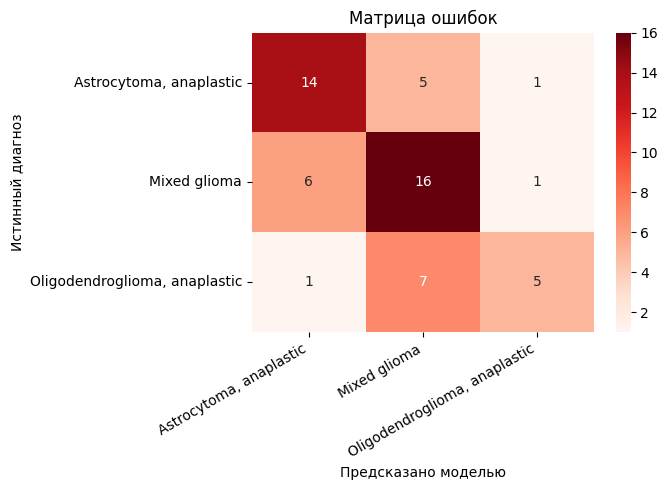

Astrocytoma, anaplastic: Чувствительность = 0.700, Специфичность = 0.806
Mixed glioma: Чувствительность = 0.696, Специфичность = 0.636
Oligodendroglioma, anaplastic: Чувствительность = 0.385, Специфичность = 0.953


In [109]:
# Лучшая модель с прошлого дз

best_model_0 = best_models[('SVM', 'subset2')]
X_tr = X_train_scaled_df[subset2]
X_te = X_test_scaled_df[subset2]
best_model_0.fit(X_tr, y_train)
y_pred_test = best_model_0.predict(X_te)
y_proba_test = best_model_0.predict_proba(X_te)

# Вычислим метрики для лучшей модели
f1 = f1_score(y_test, y_pred_test, average='weighted')
bal_acc = balanced_accuracy_score(y_test, y_pred_test)
roc_auc = roc_auc_score(y_test, y_proba_test, multi_class='ovr')
print(f"F1_weighted: {f1}")
print(f"Balanced Accuracy: {bal_acc}")
print(f"ROC_AUC_OVR: {roc_auc}")

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, cmap='Reds', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Матрица ошибок')
plt.xlabel('Предсказано моделью')
plt.ylabel('Истинный диагноз')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Вычислим специфичность и чувствительность для каждого класса
n_classes = len(label_encoder.classes_)
sensitivity = []
specificity = []
for i in range(n_classes):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - (TP + FN + FP)
    TPR = TP / (TP + FN) # чувствительность (Recall)
    TNR = TN / (TN + FP) # специфичность
    sensitivity.append(TPR)
    specificity.append(TNR)
for i in range(n_classes):
    print(f"{label_encoder.classes_[i]}: Чувствительность = {sensitivity[i]:.3f}, Специфичность = {specificity[i]:.3f}")

Лучшей моделью оказалась модель GradientBoosting с признаками, отобранными с помощью метода фильтрации, основанными на взаимной информации (F1_weighted: 0.6312647991864179), лучшая модель с прошлого дз SVM на subset2 показала следующий результ F1_weighted: 0.628932

Также можно посмотреть на метрики качества полученные на тестовой выборке

GradientBoosting:
* F1_weighted: 0.625
* Balanced Accuracy: 0.6157190635451505
* ROC_AUC_OVR: 0.7442057825146805

SVM:
* F1_weighted: 0.6176769488283119
* Balanced Accuracy: 0.593422519509476
* ROC_AUC_OVR: 0.7444883946147849

Все показатели кроме ROC_AUC_OVR(но разница незначительна) оказались лучше у GradientBoosting.

По матрице ошибок можно сказать, что GradientBoosting значительно лучше себя показал на более редком классе Oligodendroglioma, anaplastic, также можно заметить, что SVM находит больше объектов класса Mixed glioma, но при этом чаще совершает ошибки. Astrocytoma, anaplastic определеется одинаковое количество объектов, но GradientBoosting чуть чаще ошибается.

Можно сделать вывод, что более тщательный отбор признаков действительно позволил улучшить качетсво модели.